In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

import torch
import torch.nn as nn

from pathlib import Path


In [2]:
BASE_PATH = Path.cwd().parents[1]  # ajusta si tu estructura es distinta

RAW_PATH   = BASE_PATH / "data" / "raw" / "CMAPSS"
MODEL_PATH = BASE_PATH / "models" / "cmapss"
FIG_PATH   = BASE_PATH / "results" / "CMAPSS" / "GRU"

os.makedirs(FIG_PATH, exist_ok=True)

WINDOW_SIZE = 30
FD_LIST = ["FD001", "FD002", "FD003", "FD004"]

FEATURE_COLS = (
    ['setting_1','setting_2','setting_3'] +
    [f's_{i}' for i in range(1,22)]
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

Carga CMAPSS

In [3]:
def load_fd_dataset(fd):
    col_names = (
        ['unit_nr','time_cycles','setting_1','setting_2','setting_3'] +
        [f's_{i}' for i in range(1,22)]
    )

    train_file = RAW_PATH / f"train_{fd}.txt"
    test_file  = RAW_PATH / f"test_{fd}.txt"
    rul_file   = RAW_PATH / f"RUL_{fd}.txt"

    train_df = pd.read_csv(train_file, sep='\s+', header=None, names=col_names)
    test_df  = pd.read_csv(test_file,  sep='\s+', header=None, names=col_names)
    rul_df   = pd.read_csv(rul_file,   sep='\s+', header=None, names=['RUL'])

    return train_df, test_df, rul_df


Cálculo RUL en entrenamiento

In [4]:
def add_rul(train_df):
    max_cycles = (
        train_df
        .groupby('unit_nr')['time_cycles']
        .max()
        .reset_index()
        .rename(columns={'time_cycles':'max_cycle'})
    )

    df = train_df.merge(max_cycles, on='unit_nr', how='left')
    df['RUL'] = df['max_cycle'] - df['time_cycles']
    return df.drop(columns=['max_cycle'])


Escalado

In [5]:
def scale_using_saved(train_df, test_df, feature_cols, scaler):

    train_df[feature_cols] = train_df[feature_cols].fillna(train_df[feature_cols].mean())
    test_df[feature_cols]  = test_df[feature_cols].fillna(train_df[feature_cols].mean())

    try:
        train_df[feature_cols] = scaler.transform(train_df[feature_cols])
        test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

    except Exception as e:
        warnings.warn(
            f"Scaler unloadable: {e}. Refit scaler from train_df (risky)."
        )
        from sklearn.preprocessing import StandardScaler
        sc = StandardScaler()
        train_df[feature_cols] = sc.fit_transform(train_df[feature_cols])
        test_df[feature_cols]  = sc.transform(test_df[feature_cols])

    return train_df, test_df


Ventana Final

In [6]:
def create_last_window_test(test_df, rul_df, feature_cols, window_size=30):

    X_test, y_test = [], []

    for i, unit in enumerate(sorted(test_df['unit_nr'].unique())):
        unit_df = (
            test_df[test_df['unit_nr'] == unit]
            .sort_values(by='time_cycles')
        )

        seq = unit_df[feature_cols].values

        if len(seq) < window_size:
            padding = np.zeros((window_size - len(seq), seq.shape[1]))
            seq = np.vstack([padding, seq])
        else:
            seq = seq[-window_size:]

        X_test.append(seq)
        y_test.append(rul_df.iloc[i, 0])

    return np.array(X_test), np.array(y_test)


MODELO GRU FINAL

In [7]:
class GRUModel(nn.Module):

    def __init__(self, input_dim, hidden_dim1=256, hidden_dim2=128, dropout=0.3):
        super().__init__()

        self.gru1 = nn.GRU(
            input_dim, hidden_dim1,
            num_layers=2, dropout=dropout,
            batch_first=True
        )

        self.gru2 = nn.GRU(
            hidden_dim1, hidden_dim2,
            num_layers=2, dropout=dropout,
            batch_first=True
        )

        self.linear = nn.Linear(hidden_dim2, 1)

    def forward(self, x):
        out, _ = self.gru1(x)
        out, _ = self.gru2(out)
        out = out[:, -1, :]
        return self.linear(out)


NASA SCORE

In [8]:
def nasa_score(y_true, y_pred):
    e = y_pred - y_true
    score = np.where(
        e < 0,
        np.exp(-e / 13.0) - 1.0,
        np.exp(e / 10.0) - 1.0
    )
    return np.sum(score)


Visualizar RUL

In [9]:
def plot_rul_lines(fd, y_true, y_pred, figpath, suffix=""):

    os.makedirs(figpath, exist_ok=True)

    idx = np.arange(len(y_true))
    plt.figure(figsize=(10,5))

    plt.plot(idx, y_true, '-o', markersize=4, label='RUL real')
    plt.plot(idx, y_pred, '-o', markersize=4, label='RUL predicho')

    plt.xlabel("Unidad (índice)")
    plt.ylabel("RUL")
    plt.title(f"{fd} - RUL real vs predicho{suffix}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(figpath / f"{fd}_rul_lines{suffix}.png")
    plt.show()


Evaluacion

In [ ]:
results = []
all_true = []
all_pred = []

for fd in FD_LIST:

    print(f"\nProcessing {fd}")

    train_df, test_df, rul_df = load_fd_dataset(fd)
    train_df = add_rul(train_df)

    scaler_path = MODEL_PATH / f"scaler_{fd}.pkl"
    model_path  = MODEL_PATH / f"best_model_{fd}.pth"

    if not scaler_path.exists() or not model_path.exists():
        print(f"Missing scaler/model for {fd}, skipping.")
        continue

    scaler = joblib.load(scaler_path)

    train_df_s, test_df_s = scale_using_saved(
        train_df.copy(), test_df.copy(),
        FEATURE_COLS, scaler
    )

    X_test, y_true = create_last_window_test(
        test_df_s, rul_df,
        FEATURE_COLS, WINDOW_SIZE
    )

    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

    model = GRUModel(len(FEATURE_COLS)).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    with torch.no_grad():
        y_pred = model(X_test_t).cpu().numpy().flatten()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    ns = nasa_score(y_true, y_pred)

    print(f"{fd} BEFORE calib -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, NASA: {ns:.3f}")

    results.append({
        'fd': fd,
        'n_samples': len(y_true),
        'MAE_before': mae,
        'RMSE_before': rmse,
        'NASA_before': ns
    })

    all_true.append(y_true)
    all_pred.append(y_pred)

    plot_rul_lines(fd, y_true, y_pred, FIG_PATH, "_before")



Processing FD001


C:\Users\David\AppData\Local\Temp\ipykernel_6840\298668420.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev


Processing FD002


C:\Users\David\AppData\Local\Temp\ipykernel_6840\298668420.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev


Processing FD003


C:\Users\David\AppData\Local\Temp\ipykernel_6840\298668420.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev


Processing FD004


C:\Users\David\AppData\Local\Temp\ipykernel_6840\298668420.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev

Metricas y graficas PreCalibrado

FD004 BEFORE calib -> MAE: 32.097, RMSE: 42.350, NASA: 1060574.025


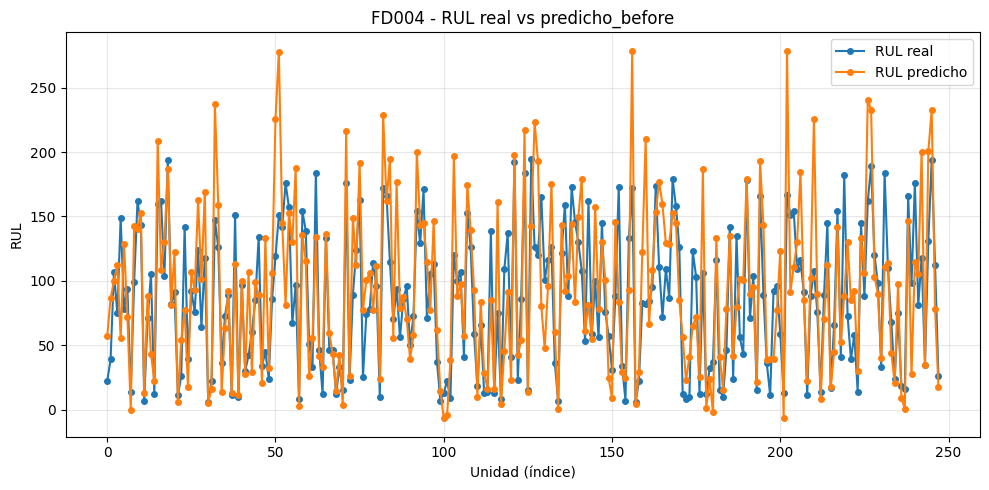

Calibracion lineal

In [ ]:
    lr = LinearRegression()
    lr.fit(y_pred.reshape(-1,1), y_true)

    y_pred_cal = lr.predict(y_pred.reshape(-1,1))

    mae_c = mean_absolute_error(y_true, y_pred_cal)
    rmse_c = np.sqrt(np.mean((y_true - y_pred_cal)**2))
    ns_c = nasa_score(y_true, y_pred_cal)

    print(f"{fd} AFTER  calib -> MAE: {mae_c:.3f}, RMSE: {rmse_c:.3f}, NASA: {ns_c:.3f}")

    results[-1].update({
        'MAE_after': mae_c,
        'RMSE_after': rmse_c,
        'NASA_after': ns_c,
        'calib_coef': lr.coef_.item(),
        'calib_intercept': lr.intercept_.item()
    })

    plot_rul_lines(fd, y_true, y_pred_cal, FIG_PATH, "_after")

    pd.DataFrame({
        'RUL_true': y_true,
        'RUL_pred': y_pred,
        'RUL_pred_cal': y_pred_cal
    }).to_csv(FIG_PATH / f"{fd}_predictions.csv", index=False)
